In [355]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

In [356]:
data = pd.read_csv('Housing.csv')
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


### uni variable Linear regression 

In [357]:
dt = data.sort_values(by='area')

Text(0.5, 1.0, 'price VS area')

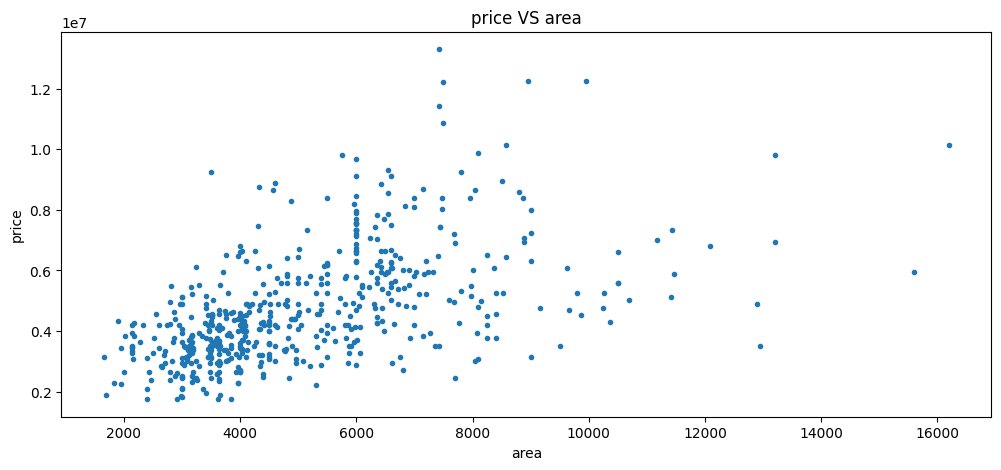

In [358]:
x = dt['area']
y = dt['price']

plt.figure(figsize=(12,5))
plt.plot(x,y,'.')
plt.xlabel('area')
plt.ylabel('price')
plt.title("price VS area")

In [359]:
# Normalize data 
x = (x - np.mean(x)) / np.std(x)
y = (y- np.mean(y)) / np.std(y)

In [360]:
# parameters and hyper parameters setting 
alpha = 0.01
# inintialize weights and bias to zero 
w = 0
b = 0 

In [361]:
# functino to compute cost function 
def compute_cost_uniLi_R(x,y,w,b):
    """
    Compute the cost for univariate linear regression.

    Args:
    x (array-like): Feature values (e.g., area).
    y (array-like): Target values (e.g., price).
    w (float): Weight parameter.
    b (float): Bias parameter.

    Returns:
    float: Computed cost.
    """
    # n = 1 # one feature [area]
    m = x.shape[0] # number of data points

    cost_sum = 0.0
    for i in range(m):
        yhat = w*x[i] + b  
        cost_sum += (yhat - y[i]) ** 2
        
    cost = (1 / (2 * m)) * cost_sum
    return cost

In [362]:
linear_cost_uni = compute_cost_uniLi_R(x,y,w,b)
print(f'linear regressin , one variable cost function = {linear_cost_uni}')

linear regressin , one variable cost function = 0.5000000000000011


In [363]:
# compute gradient desscent 
def gradient_descent_uniLIR(x,y,alpha,w,b,iter):

    m = x.shape[0] # number of data points
    cost_list = [] # store the cost after each iteration 

    while iter>0: 
        djw_tmp = 0 
        djb_tmp = 0

        for i in range(m):
            yhat = w*x[i] + b 
            djw_tmp += (yhat - y[i]) * x[i]
            djb_tmp += (yhat - y[i])

        djw = djw_tmp / m  
        djb = djb_tmp / m 

        # update parametrs 
        w = w - alpha * djw
        b = b - alpha * djb

        # compute the cost after updating w,b 
        cost = compute_cost_uniLi_R(x,y,w,b)
        cost_list.append(cost)

        iter -= 1

        print(f"Iteration {iter}: Cost = {cost}, w = {w}, b = {b}")
    return cost_list , w , b 


In [364]:
c,wn,bn = gradient_descent_uniLIR(x,y,alpha=0.01,w=0,b=0,iter=100)
# print("cost fnction list = ",c)
# print(f'final w = {wn}')
# print(f'final b = {bn}')

Iteration 99: Cost = 0.4971414331109224, w = 0.005359973457780806, b = -2.9904722938527154e-18
Iteration 98: Cost = 0.49433975170293754, w = 0.010666347180983797, b = -1.686724154843357e-18
Iteration 97: Cost = 0.4915938237549713, w = 0.01591965716695476, b = -2.9334333127710547e-19
Iteration 96: Cost = 0.48890253977317033, w = 0.021120434053066017, b = -1.0063305947978482e-18
Iteration 95: Cost = 0.4862648123426079, w = 0.026269203170316155, b = -2.1226649388246114e-18
Iteration 94: Cost = 0.4836795756879121, w = 0.031366484596393795, b = -6.722451341767004e-19
Iteration 93: Cost = 0.48114578524264456, w = 0.036412793208210656, b = 2.5667541486746737e-18
Iteration 92: Cost = 0.4786624172272389, w = 0.04140863873390935, b = 2.5423088710682483e-18
Iteration 91: Cost = 0.4762284682353395, w = 0.04635452580435106, b = 1.0185532336010611e-19
Iteration 90: Cost = 0.47384295482837846, w = 0.05125095400408835, b = -1.5644977668112298e-18
Iteration 89: Cost = 0.4715049131382162, w = 0.05609841

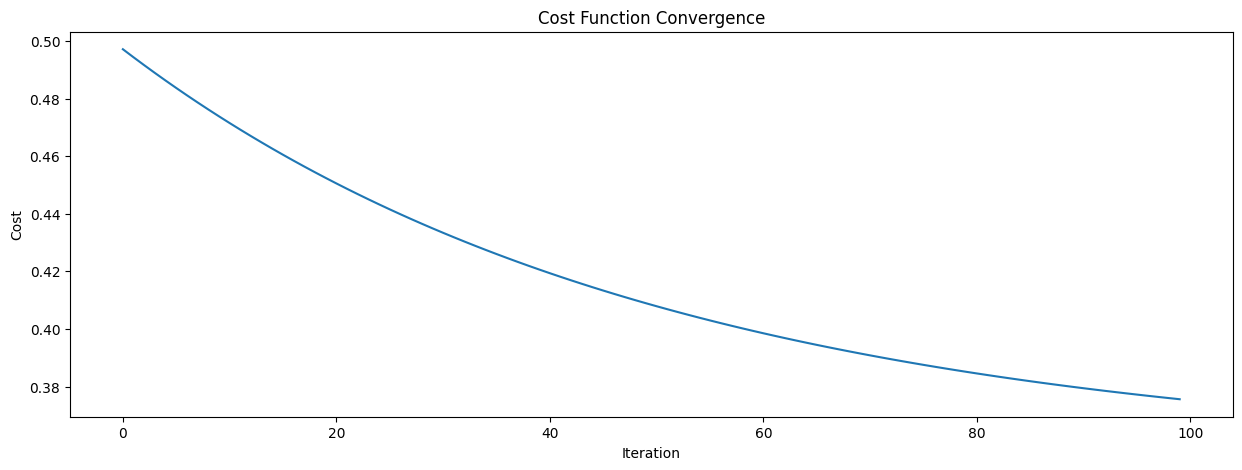

In [365]:
# plot the cost over iterations 
plt.figure(figsize=(15,5))
plt.plot(c) # c = cost 
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost Function Convergence")
plt.show()

### multi variable Linear regression 

In [366]:
datan = data
y = datan['price'] 
x1 = datan['area']
x2 = datan['bedrooms'] 
x3 = datan['bathrooms']


In [367]:
# Normalize data 
x1 = (x1 - np.mean(x1)) / np.std(x1)
x2 = (x2 - np.mean(x2)) / np.std(x2)
x3 = (x3 - np.mean(x3)) / np.std(x3)

y = (y- np.mean(y)) / np.std(y)

In [368]:
# parameters and hyper parameters setting 
alpha = 0.01
# inintialize weights and bias to zero 
w1 = 0
w2 = 0
w3 = 0
b = 0 

In [369]:
# functino to compute cost function 
def compute_cost_multiLi_R(x1,x2,x3,y,w1,w2,w3,b):
    """
    Compute the cost for univariate linear regression.

    Args:
    x (array-like): Feature values (e.g., area).
    y (array-like): Target values (e.g., price).
    w (float): Weight parameter.
    b (float): Bias parameter.

    Returns:
    float: Computed cost.
    """
    # n = 1 # one feature [area]
    m = y.shape[0] # number of data points

    cost_sum = 0.0
    for i in range(m):
        yhat = w1*x1[i] + w2*x2[i]+ w3*x3[i] + b  
        cost_sum += (yhat - y[i]) ** 2
        
    cost = (1 / (2 * m)) * cost_sum
    return cost

In [370]:
linear_cost_multi = compute_cost_multiLi_R(x1,x2,x3,y,w1,w2,w3,b)
print(f'linear regressin , multi variable cost function = {linear_cost_multi}')

linear regressin , multi variable cost function = 0.500000000000001


In [371]:
# compute gradient desscent 
def gradient_descent_multiLIR(x1,x2,x3,y,alpha,w1,w2,w3,b,iter):

    m = y.shape[0] # number of data points
    cost_list = [] # store the cost after each iteration 

    while iter>0: 
        djw1_tmp = 0 
        djw2_tmp = 0
        djw3_tmp = 0
        djb_tmp = 0

        for i in range(m):
            yhat = w1*x1[i] + w2*x2[i]+ w3*x3[i] + b  
            djw1_tmp += (yhat - y[i]) * x1[i]
            djw2_tmp += (yhat - y[i]) * x2[i]
            djw3_tmp += (yhat - y[i]) * x3[i]
    
            djb_tmp += (yhat - y[i])

        djw1 = djw1_tmp / m   
        djw2 = djw2_tmp / m
        djw3 = djw3_tmp / m
        djb = djb_tmp / m 

        # update parametrs 
        w1 = w1 - alpha * djw1
        w2 = w2 - alpha * djw2
        w3 = w3 - alpha * djw3
        b = b - alpha * djb

        # compute the cost after updating w,b 
        cost = compute_cost_multiLi_R(x1,x2,x3,y,w1,w2,w3,b)
        cost_list.append(cost)

        iter -= 1

        print(f"Iteration {iter}: Cost = {cost}, w1 = {w1},w2 = {w2},w3 = {w3}, b = {b}")
    return cost_list , w1, w2, w3 , b 


In [372]:
iter= 100
c,w1n,w2n,w3n,bn = gradient_descent_multiLIR(x1,x2,x3,y,alpha,w1,w2,w3,b,iter)


Iteration 99: Cost = 0.49315528349299326, w1 = 0.005359973457780806,w2 = 0.0036649402577386774,w3 = 0.005175453394550115, b = -3.968283398109734e-18
Iteration 98: Cost = 0.48650734893291164, w1 = 0.010650750618712049,w2 = 0.0072657389532889225,w3 = 0.010275059259980342, b = -2.5993478521499082e-18
Iteration 97: Cost = 0.4800504633654895, w1 = 0.01587326785749245,w2 = 0.010803426199565697,w3 = 0.015299950032214788, b = -1.796727904072272e-18
Iteration 96: Cost = 0.47377906214853666, w1 = 0.02102844842587786,w2 = 0.01427901615187006,w3 = 0.02025124115603761, b = 2.2285944751191216e-18
Iteration 95: Cost = 0.4676877439884181, w1 = 0.026117202641075865,w2 = 0.01769350725092862,w3 = 0.025130031340109597, b = 2.7949100730013116e-18
Iteration 94: Cost = 0.4617712661232905, w1 = 0.031140428071393,w2 = 0.021047882462262895,w3 = 0.029937402808160617, b = 3.3775225226211185e-18
Iteration 93: Cost = 0.4560245396487505, w1 = 0.03609900971917522,w2 = 0.024343109511943812,w3 = 0.034674421546415264, b

### note 
- we can observe the multi linear regression model, has lower cost as we have more features.


-- uni linear cost = 0.37 
-- multi linear cost = 0.27

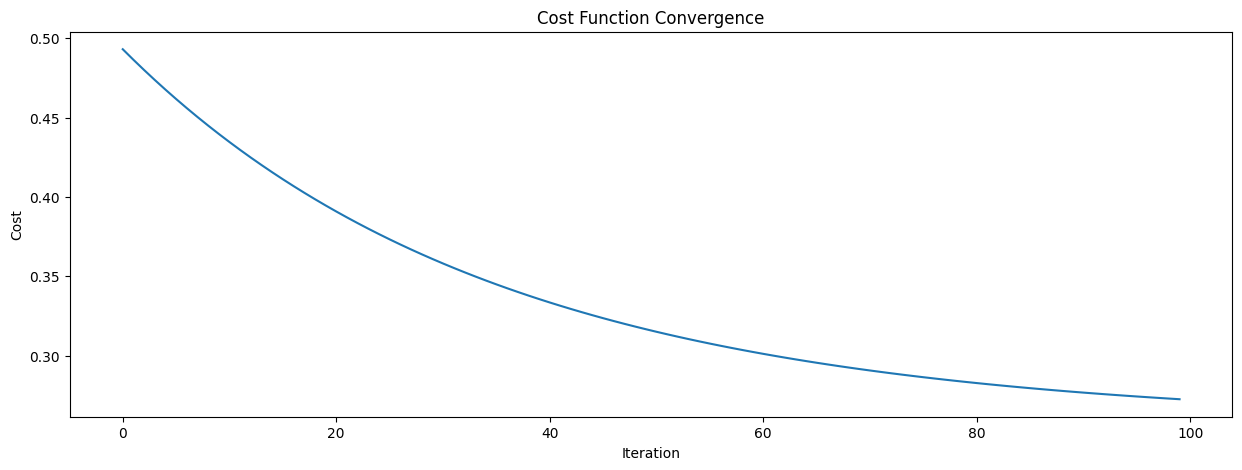

In [373]:
# plot the cost over iterations 
plt.figure(figsize=(15,5))
plt.plot(c) # c = cost 
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost Function Convergence")
plt.show()

### vectorized linear regression model 

In [ ]:
# nora=malized data 
normalized_data = data[['area',	'bedrooms',	'bathrooms','price']].copy()
mu, sigma = [],[]
# Normalize data 
for col in normalized_data.columns:
    mu.append(normalized_data[col].mean()) # get mean of each column
    sigma.append(normalized_data[col].std()) # get standard deviation of each column
    normalized_data[col] = (normalized_data[col] - normalized_data[col].mean()) / normalized_data[col].std()


[2170.141022508803, 0.7380638605685743, 0.5024696160532146, 1870439.6156573922]

In [ ]:
# convert to arrays
x = normalized_data[['area','bedrooms',	'bathrooms']].to_numpy()
y = normalized_data['price'].to_numpy()


In [376]:

# Ensure y is 2D (column vector)
y = y.reshape(-1, 1)  # Reshape to (m, 1)
print("Shape of y:", y.shape)  # Example: (3, 1)

Shape of y: (545, 1)


In [377]:
# parameters and hyper parameters setting 
alpha = 0.01
# inintialize weights and bias to zero 
w = np.zeros((x.shape[1],1)) # weights size = number of features
b = 0 

In [378]:
# functino to compute cost function 
def compute_cost(x,y,w,b):
    """
    Compute the cost for univariate linear regression.

    Args:
    x (array-like): Feature values (e.g., area).
    y (array-like): Target values (e.g., price).
    w (float): Weight parameter.
    b (float): Bias parameter.

    Returns:
    float: Computed cost.
    """
    # n = 1 # one feature [area]
    m = x.shape[0] # number of data points

    yhat = x.dot(w) + b 
    J = (1/(2*m)) * np.sum(np.square(y-yhat))
  
    return (J)

In [379]:
# determince cost function 
J = compute_cost(x,y,w,b)
print('cost before training = ', J)

cost before training =  0.4990825688073395


In [385]:
# compute gradient desscent 
def gradient_descent(x,y,alpha,w,b,iter):

    m = y.shape[0] # number of data points
    cost_list = [] # store the cost after each iteration 
    w1list, w2list ,w3list, blist = [] , [] , [], []

    while iter>0: 
        # djw_tmp = np.zeros((x.shape[1],1))
        # djb_tmp = 0
        # print(djw_tmp.shape)
       
        yhat = x.dot(w) + b  
        djw_tmp = (x.T.dot(yhat - y))/ m
        djb_tmp = np.sum((yhat - y)) /m 
       
        # print(djw_tmp.shape)
        # update parametrs 
        w = w - alpha * djw_tmp
        b = b - alpha * djb_tmp

        # compute the cost after updating w,b 
        J = compute_cost(x,y,w,b)
        cost_list.append(J)
        w1list.append(w[0])
        w2list.append(w[1])
        w3list.append(w[2])
        blist.append(b)
        iter -= 1

        print(f"Iteration {iter}: Cost = {J}, w = {w}, b = {b}")
    return cost_list , w , b , w1list,w2list,w3list ,blist


In [386]:
iter= 100
costf,wf,bf ,w1list,w2list,w3list ,blist= gradient_descent(x,y,alpha,w,b,iter)


Iteration 99: Cost = 0.4922628562111822, w = [[0.00535014]
 [0.00365822]
 [0.00516596]], b = 2.0859970224149732e-18
Iteration 98: Cost = 0.4856388496538427, w = [[0.01063133]
 [0.00725252]
 [0.01025634]], b = 4.1719940448299465e-18
Iteration 97: Cost = 0.4792048579087348, w = [[0.01584452]
 [0.01078395]
 [0.01527229]], b = 5.736491811641176e-18
Iteration 96: Cost = 0.4729553565320144, w = [[0.02099061]
 [0.01425351]
 [0.0202149 ]], b = 7.82248883405615e-18
Iteration 95: Cost = 0.4668849829531189, w = [[0.02607051]
 [0.01766218]
 [0.02508527]], b = 9.38698660086738e-18
Iteration 94: Cost = 0.46098853171019755, w = [[0.03108512]
 [0.02101095]
 [0.02988447]], b = 1.1472983623282353e-17
Iteration 93: Cost = 0.45526094982614973, w = [[0.03603532]
 [0.02430078]
 [0.03461357]], b = 1.3037481390093584e-17
Iteration 92: Cost = 0.44969733232111714, w = [[0.04092196]
 [0.02753262]
 [0.03927361]], b = 1.56449776681123e-17
Iteration 91: Cost = 0.4442929178573944, w = [[0.04574592]
 [0.0307074 ]
 [0

In [387]:
print(f'cost  = {costf} , \n , w final = {wf} \n b final = {bf} ')

cost  = [0.4922628562111822, 0.4856388496538427, 0.4792048579087348, 0.4729553565320144, 0.4668849829531189, 0.46098853171019755, 0.45526094982614973, 0.44969733232111714, 0.4442929178573944, 0.439043084512846, 0.43394334567903203, 0.42898934608035577, 0.42417685791065785, 0.4195017770837855, 0.4149601195947704, 0.41054801798834323, 0.40626171793161797, 0.4020975748878644, 0.39805205088838236, 0.3941217113995812, 0.3903032222824499, 0.38659334684168833, 0.38298894296185154, 0.3794869603279354, 0.37608443772791117, 0.3727785004347852, 0.3695663576658374, 0.366445300116757, 0.36341269756846406, 0.3604659965644704, 0.35760271815669475, 0.35482045571771276, 0.35211687281747783, 0.34948970116261, 0.34693673859640495, 0.3444558471577697, 0.3420449511973455, 0.33970203554912926, 0.3374251437559541, 0.33521237634723994, 0.3330618891674707, 0.3309718917538995, 0.3289406457620297, 0.3269664634374612, 0.32504770613273337, 0.3231827828678353, 0.32137014893309673, 0.31960830453320693, 0.31789579347

In [388]:
print(f"final cost = {costf[-1]}")

final cost = 0.2721045485306439


### Note: 
cost is the same result as manual multilinear regression

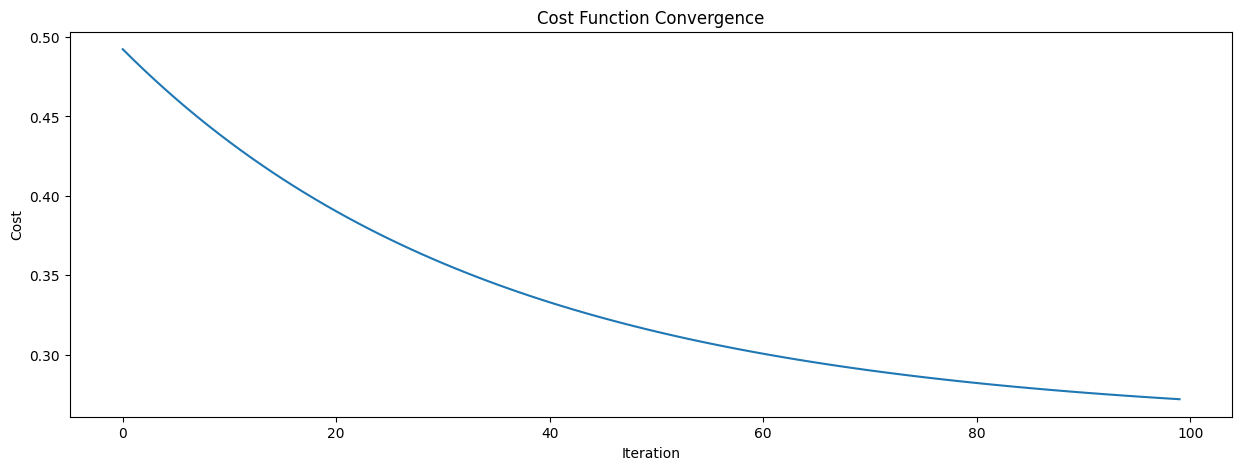

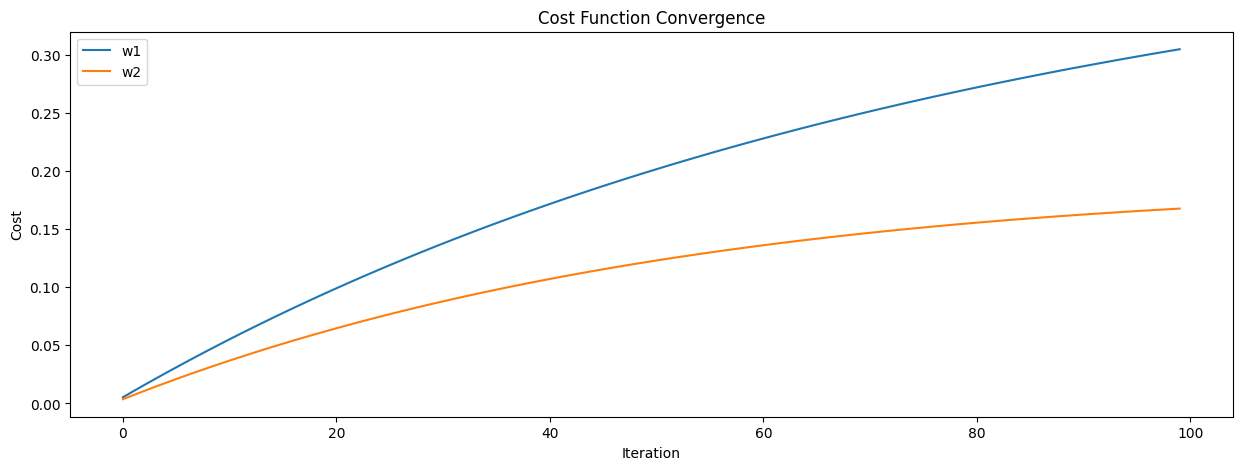

In [ ]:
# plot the cost over iterations 
plt.figure(figsize=(15,5))
plt.plot(costf) # c = cost 
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost Function Convergence")
plt.show()



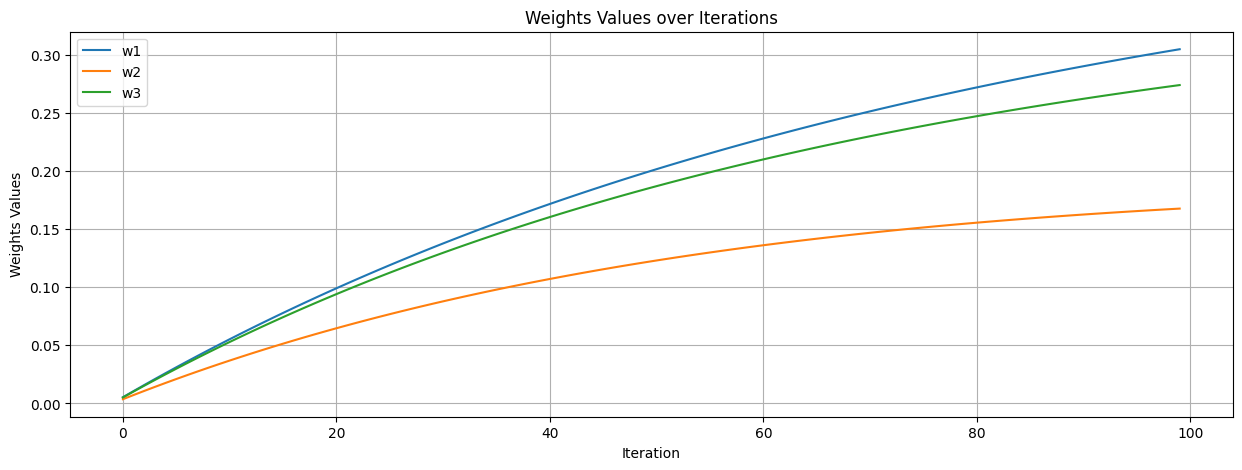

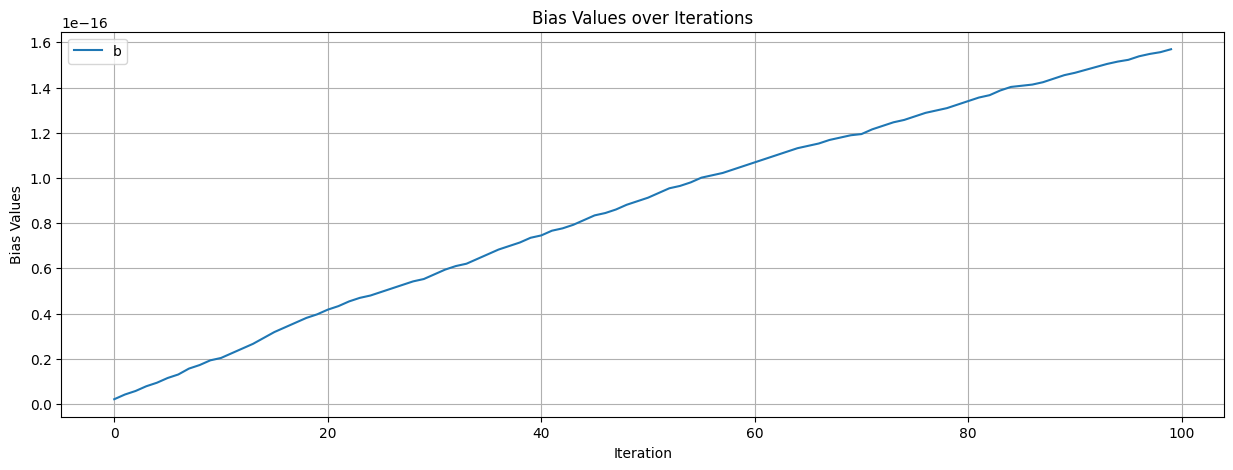

In [401]:

# plot the weights and bias [parameters] over iterations 
plt.figure(figsize=(15,5))
plt.plot(w1list, label = 'w1') 
plt.plot(w2list, label = 'w2')
plt.plot(w3list, label = 'w3')

plt.legend()
plt.xlabel("Iteration")
plt.ylabel("Weights Values")
plt.title("Weights Values over Iterations")
plt.grid(True)
plt.show()


# plot the bias 
plt.figure(figsize=(15,5))
plt.plot(blist, label = 'b') 
plt.legend()
plt.xlabel("Iteration")
plt.ylabel("Bias Values")
plt.title("Bias Values over Iterations")
plt.grid(True)
plt.show()

## Estimation 

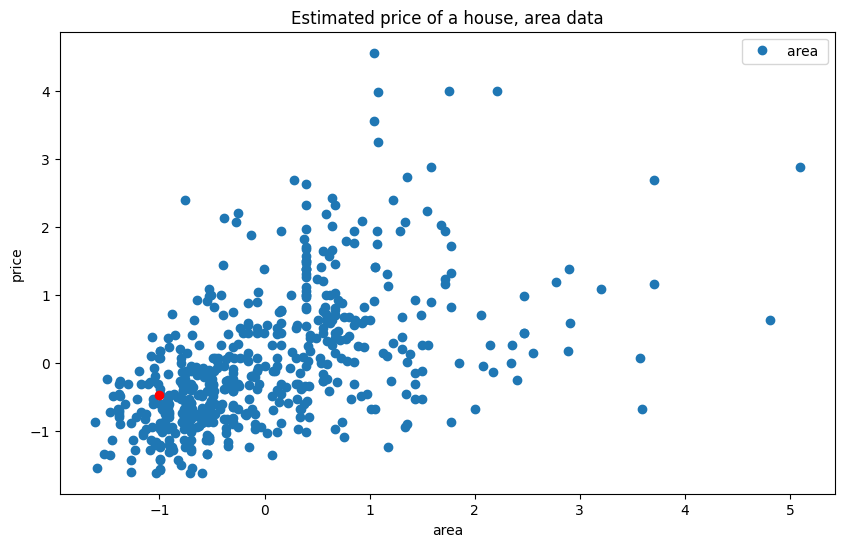

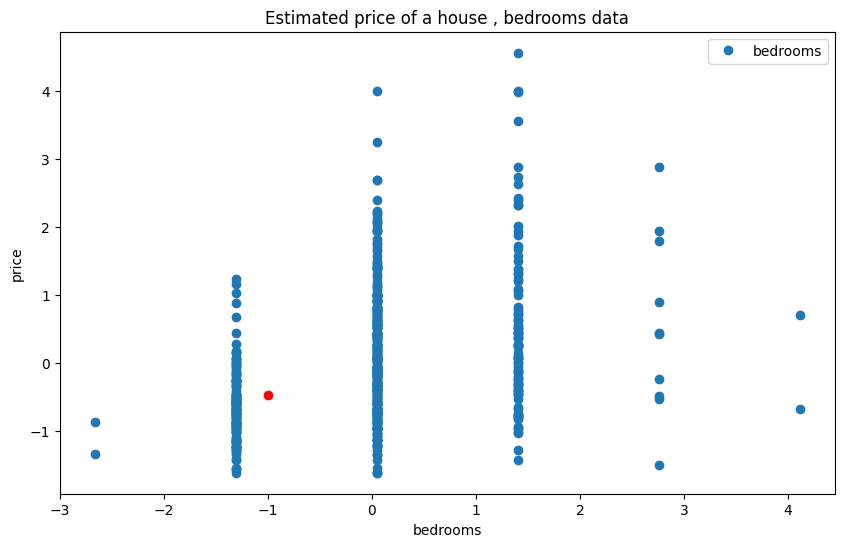

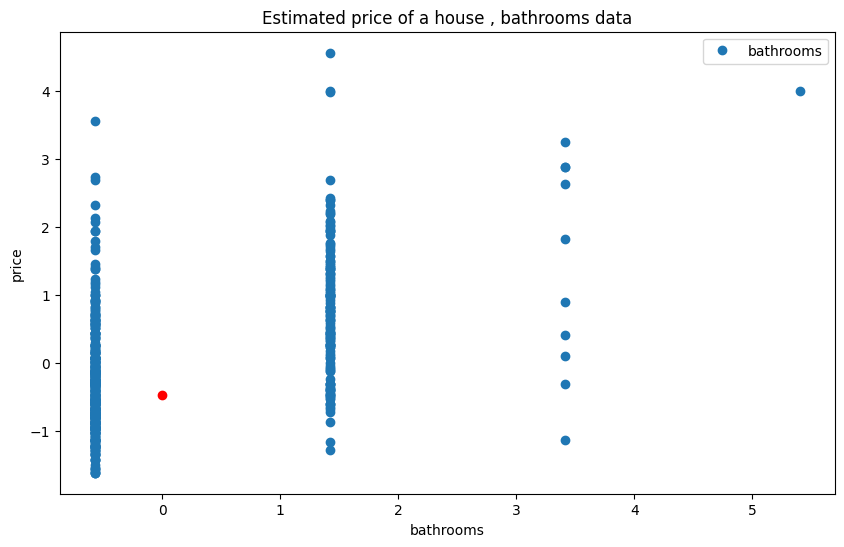

In [462]:
# Estimate the price of a 1650 sq-ft, 3 br house

# Normalize the input data 
feature_in = np.array([1200, 2, 1])
for i in range(3):
    feature_in[i] = (feature_in[i] - mu[i]) / sigma[i]

feature_in

y_pred = feature_in.dot(wf) + bf
y_pred

# plot the estimated value 
plt.figure(figsize=(10, 6))
plt.plot(x[:,0], y, 'o', label='area ')
plt.plot(feature_in[0],y_pred,'o',color = 'red')
plt.xlabel('area')
plt.ylabel('price')
plt.title('Estimated price of a house, area data')
plt.legend()

plt.figure(figsize=(10, 6))
plt.plot(x[:,1], y, 'o', label='bedrooms')
plt.plot(feature_in[1],y_pred,'o',color = 'red')
plt.xlabel('bedrooms')
plt.ylabel('price')
plt.title('Estimated price of a house , bedrooms data')
plt.legend()


plt.figure(figsize=(10, 6))
plt.plot(x[:,2], y, 'o', label='bathrooms')
plt.plot(feature_in[2],y_pred,'o',color = 'red')
plt.xlabel('bathrooms')
plt.ylabel('price')
plt.title('Estimated price of a house , bathrooms data')
plt.legend()


Iteration 99: Cost = 0.30865836243949385, w = [[0.53501386]
 [0.36582156]
 [0.51659571]], b = 2.0859970224149731e-16
Iteration 98: Cost = 0.26860202180618115, w = [[0.38060174]
 [0.09257916]
 [0.27749698]], b = 2.998620719721524e-16
Iteration 97: Cost = 0.2590334052467832, w = [[0.46799343]
 [0.20472576]
 [0.40891756]], b = 2.737871091919652e-16
Iteration 96: Cost = 0.25672432286718333, w = [[0.42572948]
 [0.14263275]
 [0.3503935 ]], b = 3.520119975325267e-16
Iteration 95: Cost = 0.25616609915831173, w = [[0.44638628]
 [0.17076895]
 [0.38163852]], b = 2.737871091919652e-16
Iteration 94: Cost = 0.25603103857942555, w = [[0.43611452]
 [0.1560274 ]
 [0.36719783]], b = 2.998620719721524e-16
Iteration 93: Cost = 0.2559983459153921, w = [[0.44112394]
 [0.16294724]
 [0.37466075]], b = 2.737871091919652e-16
Iteration 92: Cost = 0.25599043019193907, w = [[0.43864042]
 [0.15941512]
 [0.37112251]], b = 3.2593703475233955e-16
Iteration 91: Cost = 0.25598851328546907, w = [[0.43985578]
 [0.16110572

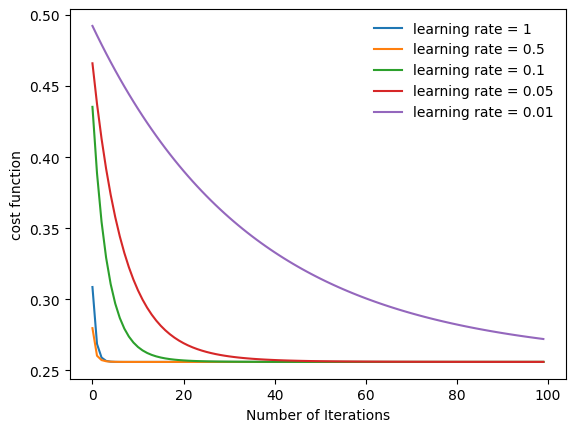

In [465]:
iter= 100
learning_rate = [1, 0.5, 0.1, 0.05, 0.01]
J = [] 
for i in range(len(learning_rate)):
    costf,wf,bf ,w1list,w2list,w3list ,blist= gradient_descent(x,y,learning_rate[i],w,b,iter)
    plt.plot(costf, label = 'learning rate = %s' % learning_rate[i])
    J.append(costf[-1])

plt.ylabel(r'cost function')
plt.xlabel(r'Number of Iterations')
plt.legend(loc = 'best', frameon = False)



### Short Comment:
The results show stable convergence for learning rates `1`, `0.5`, `0.1`, and `0.05`, with all reaching similar costs (~`0.256`). However, the smallest learning rate `0.01` converges more slowly and results in a slightly higher cost (`0.272`), indicating suboptimal convergence. While larger rates like `1` work here due to the simple cost surface, `0.1` or `0.05` are safer and more reliable for general use.
